# Static Baseline Exploratory Data Analysis

This notebook analyses the static difficulty baseline results from the Godot prototype.  
Each simulated player profile was tested at static difficulty level 5.

The purpose of this analysis is to examine how different simulated player profiles perform under the same fixed difficulty setting. These results provide the baseline for later comparison with rule-based DDA and RL-based DDA.

## Creating the Combined Static Baseline Dataset

The raw CSV files generated by Godot are loaded, combined, cleaned, and saved as one processed dataset.  
The rest of the notebook uses this combined CSV file rather than repeatedly loading the individual raw files.

In [18]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

RAW_DATA_DIR = Path("../godot_project/game_project/data/raw")
PROCESSED_DATA_DIR = Path("../data/processed")
FIGURE_DIR = Path("../results/figures")
TABLE_DIR = Path("../results/tables")

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

COMBINED_DATA_PATH = PROCESSED_DATA_DIR / "static_baseline_combined.csv"

PROFILE_ORDER = [
    "beginner",
    "intermediate",
    "skilled",
    "inconsistent",
    "improving",
]

files = {
    "beginner": "static_difficulty_5_beginner_logged.csv",
    "intermediate": "static_difficulty_5_intermediate_logged.csv",
    "skilled": "static_difficulty_5_skilled_logged.csv",
    "inconsistent": "static_difficulty_5_inconsistent_logged.csv",
    "improving": "static_difficulty_5_improving_logged.csv",
}

# Backfill static CSVs with difficulty-tracking columns.
for file_name in files.values():
    file_path = RAW_DATA_DIR / file_name

    if not file_path.exists():
        print(f"Skipping missing file: {file_path}")
        continue

    df = pd.read_csv(file_path)

    if "final_difficulty" not in df.columns:
        raise ValueError(f"{file_name} does not contain final_difficulty.")

    df["final_difficulty"] = pd.to_numeric(df["final_difficulty"], errors="coerce")
    df["survival_time"] = pd.to_numeric(df["survival_time"], errors="coerce")

    # Static difficulty does not change during the run.
    df["initial_difficulty"] = df["final_difficulty"]
    df["average_difficulty"] = df["final_difficulty"]
    df["min_difficulty"] = df["final_difficulty"]
    df["max_difficulty"] = df["final_difficulty"]
    df["difficulty_changes"] = 0

    # This cannot be recovered accurately from old summary-only CSVs.
    # It will be logged properly in rule-based and RL experiments.
    df["time_in_target_range"] = pd.NA

    # Useful proxy for static baseline analysis.
    df["within_target_survival_range"] = df["survival_time"].between(
        40,
        60,
        inclusive="both",
    )

    backup_path = file_path.with_suffix(".backup.csv")

    if not backup_path.exists():
        pd.read_csv(file_path).to_csv(backup_path, index=False)

    df.to_csv(file_path, index=False)

    print(f"Updated: {file_name}")

# Load the updated raw CSV files and combine them.
frames = []

for profile, file_name in files.items():
    file_path = RAW_DATA_DIR / file_name

    df = pd.read_csv(file_path)
    df["profile"] = profile

    frames.append(df)

combined = pd.concat(frames, ignore_index=True)

combined["player_died"] = (
    combined["player_died"]
    .astype(str)
    .str.lower()
    .isin(["true", "1", "yes"])
)

numeric_columns = [
    "run_number",
    "survival_time",
    "score",
    "health_remaining",
    "hits_taken",
    "deaths",
    "final_difficulty",
    "initial_difficulty",
    "average_difficulty",
    "min_difficulty",
    "max_difficulty",
    "difficulty_changes",
    "time_in_target_range",
    "profile_speed",
    "profile_reaction_time",
    "profile_dodge_chance",
    "profile_mistake_chance",
    "profile_detection_radius",
    "profile_dodge_duration",
    "profile_strafe_weight",
    "profile_retreat_weight",
]

for column in numeric_columns:
    if column in combined.columns:
        combined[column] = pd.to_numeric(combined[column], errors="coerce")

combined["profile"] = pd.Categorical(
    combined["profile"],
    categories=PROFILE_ORDER,
    ordered=True,
)

combined = combined.sort_values(["profile", "run_number"]).reset_index(drop=True)

combined.to_csv(COMBINED_DATA_PATH, index=False)

COMBINED_DATA_PATH

Updated: static_difficulty_5_beginner_logged.csv
Updated: static_difficulty_5_intermediate_logged.csv
Updated: static_difficulty_5_skilled_logged.csv
Updated: static_difficulty_5_inconsistent_logged.csv
Updated: static_difficulty_5_improving_logged.csv


PosixPath('../data/processed/static_baseline_combined.csv')

## 1. Loading the Static Baseline Data

The CSV files generated by the Godot experiment manager are loaded and combined into one dataframe.  
Each row represents one simulation run.

In [19]:
results = pd.read_csv(COMBINED_DATA_PATH)

results["profile"] = pd.Categorical(
    results["profile"],
    categories=PROFILE_ORDER,
    ordered=True,
)

results.head()

,profile_name,system_name,run_number,player_died,survival_time,score,health_remaining,hits_taken,deaths,final_difficulty,...,profile_strafe_weight,profile_retreat_weight,initial_difficulty,average_difficulty,min_difficulty,max_difficulty,difficulty_changes,time_in_target_range,within_target_survival_range,profile
0,beginner,static,1,False,60.00,600,6.5,11,0,5,...,0.6,0.2,5,5,5,5,0,NaN,True,beginner
1,beginner,static,2,True,59.50,595,0.0,12,1,5,...,0.6,0.2,5,5,5,5,0,NaN,True,beginner
2,beginner,static,3,True,59.00,590,0.0,12,1,5,...,0.6,0.2,5,5,5,5,0,NaN,True,beginner
3,beginner,static,4,True,43.17,431,0.0,12,1,5,...,0.6,0.2,5,5,5,5,0,NaN,True,beginner
4,beginner,static,5,False,60.00,600,40.5,7,0,5,...,0.6,0.2,5,5,5,5,0,NaN,True,beginner


In [5]:
results["player_died"] = results["player_died"].astype(str).str.lower().isin(["true", "1", "yes"])

numeric_columns = [
    "run_number",
    "survival_time",
    "score",
    "health_remaining",
    "hits_taken",
    "deaths",
    "final_difficulty",
    "profile_speed",
    "profile_reaction_time",
    "profile_dodge_chance",
    "profile_mistake_chance",
    "profile_detection_radius",
    "profile_dodge_duration",
    "profile_strafe_weight",
    "profile_retreat_weight",
]

for column in numeric_columns:
    if column in results.columns:
        results[column] = pd.to_numeric(results[column], errors="coerce")

results["profile"] = pd.Categorical(
    results["profile"],
    categories=PROFILE_ORDER,
    ordered=True,
)

results = results.sort_values(["profile", "run_number"]).reset_index(drop=True)

results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   profile_name              150 non-null    object  
 1   system_name               150 non-null    object  
 2   run_number                150 non-null    int64   
 3   player_died               150 non-null    bool    
 4   survival_time             150 non-null    float64 
 5   score                     150 non-null    int64   
 6   health_remaining          150 non-null    float64 
 7   hits_taken                150 non-null    int64   
 8   deaths                    150 non-null    int64   
 9   final_difficulty          150 non-null    int64   
 10  profile_speed             150 non-null    float64 
 11  profile_reaction_time     150 non-null    float64 
 12  profile_dodge_chance      150 non-null    float64 
 13  profile_mistake_chance    150 non-null    float64 

## 2. Summary Statistics

This section summarises the static baseline results by profile.  
The key measures are deaths, survivals, death rate, average survival time, health remaining, and hits taken.

In [6]:
summary = (
    results
    .groupby("profile", observed=False)
    .agg(
        runs=("run_number", "count"),
        deaths=("player_died", "sum"),
        average_survival_time=("survival_time", "mean"),
        median_survival_time=("survival_time", "median"),
        min_survival_time=("survival_time", "min"),
        max_survival_time=("survival_time", "max"),
        average_health_remaining=("health_remaining", "mean"),
        average_hits_taken=("hits_taken", "mean"),
    )
    .reset_index()
)

summary["survivals"] = summary["runs"] - summary["deaths"]
summary["death_rate"] = (summary["deaths"] / summary["runs"]) * 100
summary["survival_rate"] = (summary["survivals"] / summary["runs"]) * 100

summary = summary[
    [
        "profile",
        "runs",
        "deaths",
        "survivals",
        "death_rate",
        "survival_rate",
        "average_survival_time",
        "median_survival_time",
        "min_survival_time",
        "max_survival_time",
        "average_health_remaining",
        "average_hits_taken",
    ]
]

summary.round(2)

,profile,runs,deaths,survivals,death_rate,survival_rate,average_survival_time,median_survival_time,min_survival_time,max_survival_time,average_health_remaining,average_hits_taken
0,beginner,30,22,8,73.33,26.67,49.45,52.25,29.25,60.0,5.13,11.33
1,intermediate,30,11,19,36.67,63.33,56.26,60.00,36.08,60.0,17.43,9.80
2,skilled,30,5,25,16.67,83.33,59.06,60.00,47.50,60.0,27.80,8.53
3,inconsistent,30,13,17,43.33,56.67,56.20,60.00,41.33,60.0,17.00,9.87
4,improving,30,17,13,56.67,43.33,52.22,59.21,19.00,60.0,11.88,10.50


Concise summary

In [7]:
for _, row in summary.iterrows():
    profile = row["profile"]
    deaths = int(row["deaths"])
    runs = int(row["runs"])
    death_rate = row["death_rate"]
    avg_survival = row["average_survival_time"]
    
    print(
        f"{profile}: {deaths}/{runs} deaths "
        f"({death_rate:.1f}% death rate), "
        f"average survival time = {avg_survival:.2f}s."
    )

beginner: 22/30 deaths (73.3% death rate), average survival time = 49.45s.
intermediate: 11/30 deaths (36.7% death rate), average survival time = 56.26s.
skilled: 5/30 deaths (16.7% death rate), average survival time = 59.06s.
inconsistent: 13/30 deaths (43.3% death rate), average survival time = 56.20s.
improving: 17/30 deaths (56.7% death rate), average survival time = 52.22s.


### Interpretation

The summary statistics show whether static difficulty level 5 is suitable for each simulated player profile.  
A medium difficulty should produce mixed outcomes, while a very high death rate suggests the difficulty is too hard and a very low death rate suggests it is too easy.

## 3. Death Rate by Profile

This chart compares the percentage of failed runs for each simulated player profile.

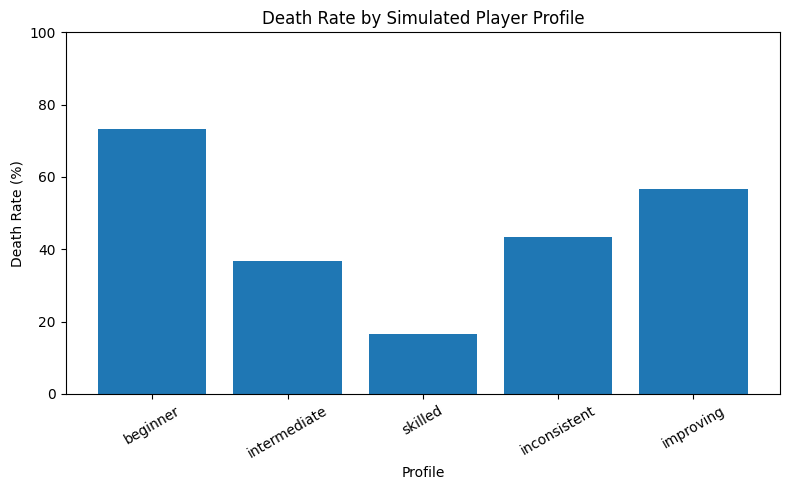

In [8]:
plt.figure(figsize=(8, 5))
plt.bar(summary["profile"].astype(str), summary["death_rate"])

plt.title("Death Rate by Simulated Player Profile")
plt.xlabel("Profile")
plt.ylabel("Death Rate (%)")
plt.ylim(0, 100)
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(FIGURE_DIR / "static_death_rate_by_profile.png", dpi=300)
plt.show()

### Interpretation

The death rate chart shows how uneven static difficulty is across profiles.  
A high death rate for the beginner profile suggests that static difficulty level 5 is too hard for weaker behaviour.  
A low death rate for the skilled profile suggests that the same difficulty is too easy for stronger behaviour.

## 4. Average Survival Time by Profile

This chart compares how long each profile survived on average during the 60-second episode.

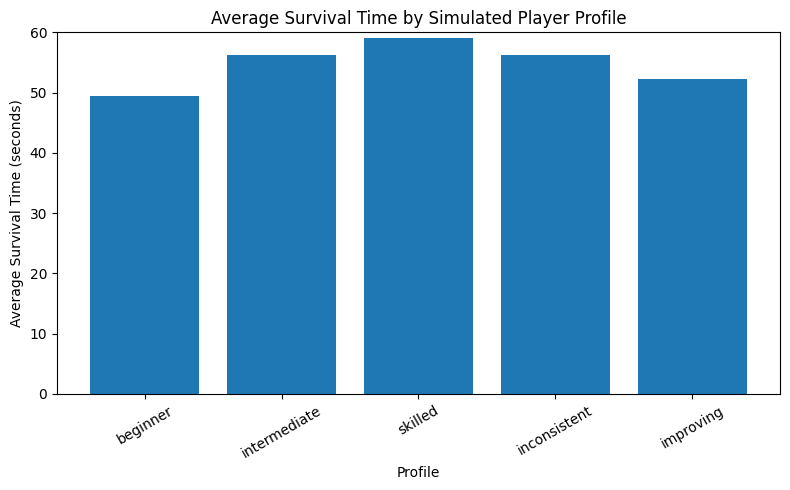

In [9]:
plt.figure(figsize=(8, 5))
plt.bar(summary["profile"].astype(str), summary["average_survival_time"])

plt.title("Average Survival Time by Simulated Player Profile")
plt.xlabel("Profile")
plt.ylabel("Average Survival Time (seconds)")
plt.ylim(0, 60)
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(FIGURE_DIR / "static_average_survival_by_profile.png", dpi=300)
plt.show()

### Interpretation

Average survival time provides another view of difficulty balance.  
Profiles that survive close to 60 seconds are experiencing the static difficulty as easier, while profiles with lower survival times are experiencing greater challenge.

## 5. Survival Time Distribution

Averages can hide variation between runs.  
The boxplot below shows the spread of survival times for each profile.

/var/folders/wr/yfqr6y3s6kzbnssvn_smcchh0000gn/T/ipykernel_69237/3928992622.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=PROFILE_ORDER)


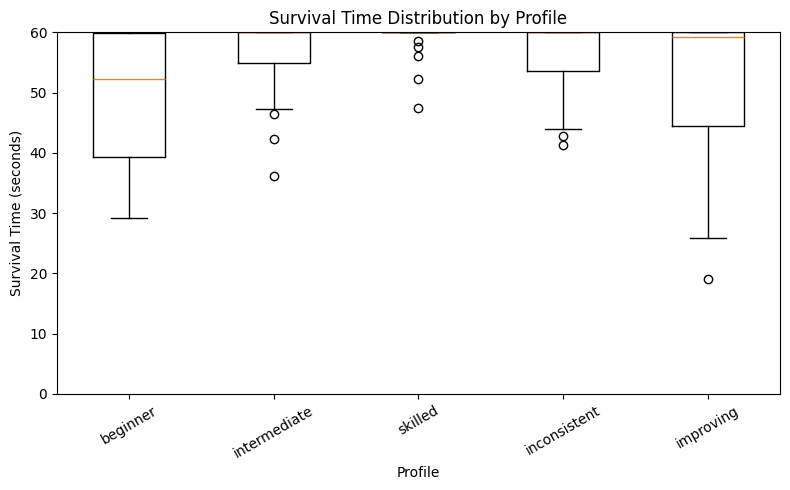

In [10]:
boxplot_data = [
    results.loc[results["profile"] == profile, "survival_time"]
    for profile in PROFILE_ORDER
]

plt.figure(figsize=(8, 5))
plt.boxplot(boxplot_data, labels=PROFILE_ORDER)

plt.title("Survival Time Distribution by Profile")
plt.xlabel("Profile")
plt.ylabel("Survival Time (seconds)")
plt.ylim(0, 60)
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(FIGURE_DIR / "static_survival_time_distribution_by_profile.png", dpi=300)
plt.show()

### Interpretation

The boxplot shows the distribution of survival times for each simulated player profile. Several profiles have values clustered at 60 seconds because each episode has a maximum duration of 60 seconds. This means that survival time is capped, which causes some boxes to appear compressed near the top of the chart.

The beginner profile shows lower and more variable survival times, while the skilled profile is concentrated near the maximum survival time. The improving profile shows a wide spread because it begins with weaker behaviour and becomes stronger across later runs. This supports the intended design of the simulated player profiles.

## 6. Health Remaining by Profile

Health remaining helps distinguish between comfortable survival and narrow survival.  
A profile may survive the full episode, but low remaining health suggests it was still under pressure.

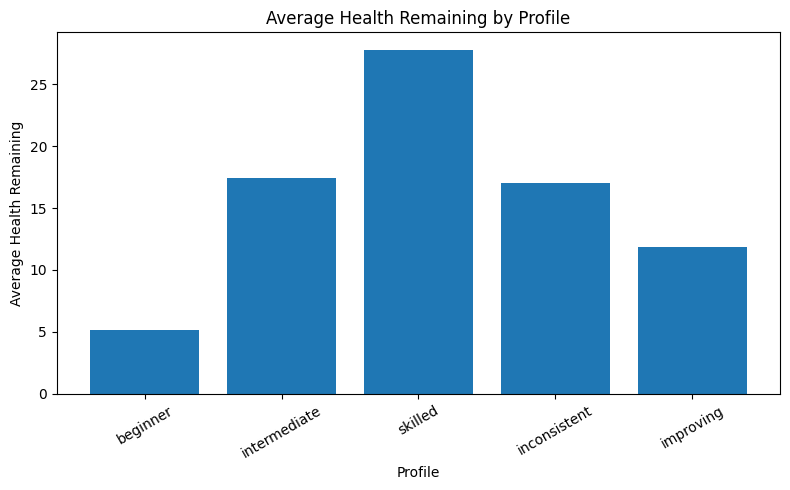

In [11]:
plt.figure(figsize=(8, 5))
plt.bar(summary["profile"].astype(str), summary["average_health_remaining"])

plt.title("Average Health Remaining by Profile")
plt.xlabel("Profile")
plt.ylabel("Average Health Remaining")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(FIGURE_DIR / "static_average_health_remaining_by_profile.png", dpi=300)
plt.show()

### Interpretation

Average health remaining provides another indication of how much pressure each profile experienced. The beginner profile had the lowest average health remaining, showing that static difficulty level 5 was too difficult for weaker simulated player behaviour. The skilled profile had the highest average health remaining, suggesting that the same difficulty level was too easy for stronger behaviour.

The intermediate profile sat between beginner and skilled, supporting its role as the calibrated medium baseline. The improving profile had lower average health overall because its early runs used weaker behaviour settings, while the inconsistent profile remained close to intermediate overall but varied between runs.

## 7. Hits Taken by Profile

Hits taken measures how often each profile was damaged during a run.  
This helps show whether profiles survived comfortably or survived after repeated damage.

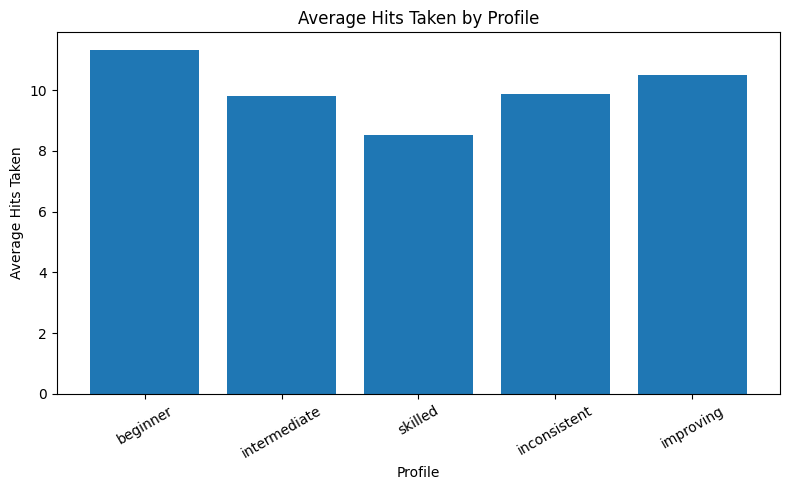

In [12]:
plt.figure(figsize=(8, 5))
plt.bar(summary["profile"].astype(str), summary["average_hits_taken"])

plt.title("Average Hits Taken by Profile")
plt.xlabel("Profile")
plt.ylabel("Average Hits Taken")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(FIGURE_DIR / "static_average_hits_taken_by_profile.png", dpi=300)
plt.show()

### Interpretation

Average hits taken shows how much pressure each simulated player profile experienced under static difficulty level 5. The beginner profile took the most hits on average, which supports the finding that static difficulty level 5 was too difficult for weaker simulated behaviour. The skilled profile took the fewest hits, suggesting that the same difficulty level was too easy for stronger behaviour.

The intermediate profile sat between beginner and skilled, supporting its role as the calibrated medium baseline. The improving profile had a relatively high average number of hits because the early runs used weaker behaviour values before the profile improved across later runs.

## 8. Improving Profile Trend

The improving profile is designed to become stronger over repeated runs.  
This plot shows whether survival time increases as the run number increases.

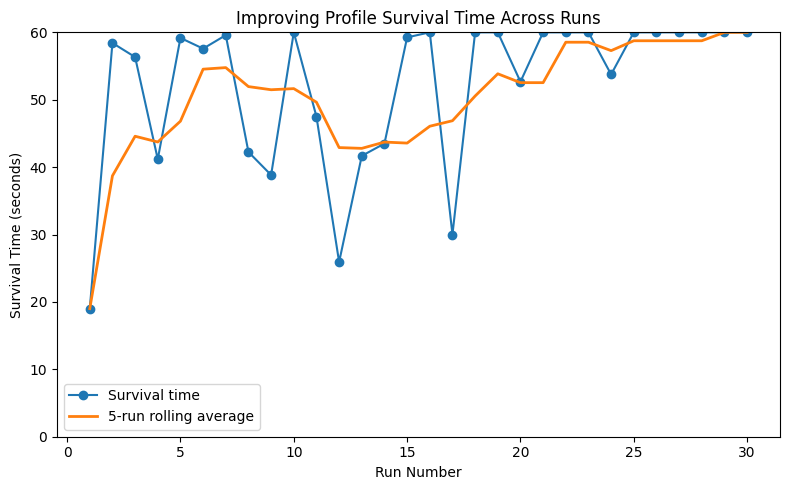

In [13]:
improving = results[results["profile"] == "improving"].copy()

improving["survival_time_rolling"] = (
    improving["survival_time"]
    .rolling(window=5, min_periods=1)
    .mean()
)

plt.figure(figsize=(8, 5))

plt.plot(
    improving["run_number"],
    improving["survival_time"],
    marker="o",
    label="Survival time"
)

plt.plot(
    improving["run_number"],
    improving["survival_time_rolling"],
    linewidth=2,
    label="5-run rolling average"
)

plt.title("Improving Profile Survival Time Across Runs")
plt.xlabel("Run Number")
plt.ylabel("Survival Time (seconds)")
plt.ylim(0, 60)
plt.legend()
plt.tight_layout()

plt.savefig(FIGURE_DIR / "improving_profile_survival_time_trend.png", dpi=300)
plt.show()

In [14]:
first_half = improving[improving["run_number"] <= 15]
second_half = improving[improving["run_number"] > 15]

first_half_deaths = first_half["player_died"].sum()
second_half_deaths = second_half["player_died"].sum()

print(f"Improving profile first 15 runs: {first_half_deaths}/15 deaths.")
print(f"Improving profile final 15 runs: {second_half_deaths}/15 deaths.")

Improving profile first 15 runs: 14/15 deaths.
Improving profile final 15 runs: 3/15 deaths.


### Interpretation

The improving profile shows a general upward trend in survival time across repeated runs. Individual runs still vary because the simulation includes random movement and projectile interactions, but the 5-run rolling average shows that performance becomes more stable over time.

Early runs include several lower survival times, while later runs more consistently reach the full 60-second episode duration. This supports the intended design of the improving profile, where behaviour parameters gradually shift from beginner-level values toward skilled-level values.

## 9. Improving Profile Parameter Progression

This section checks whether the improving profile's internal behaviour values change across runs.

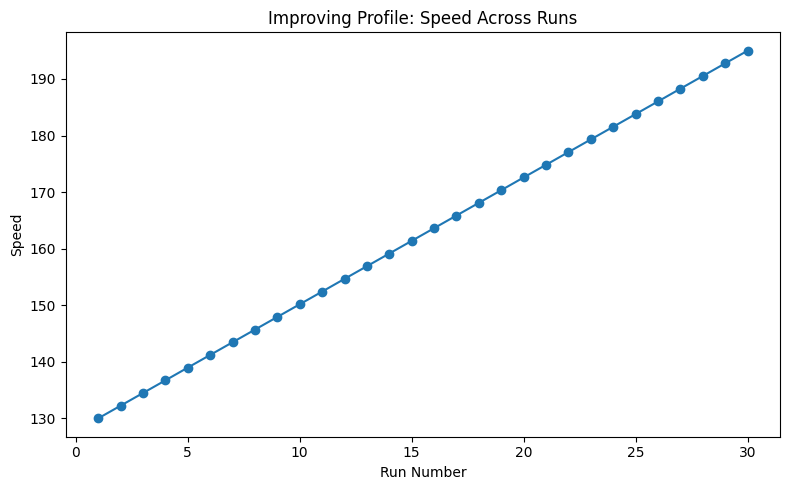

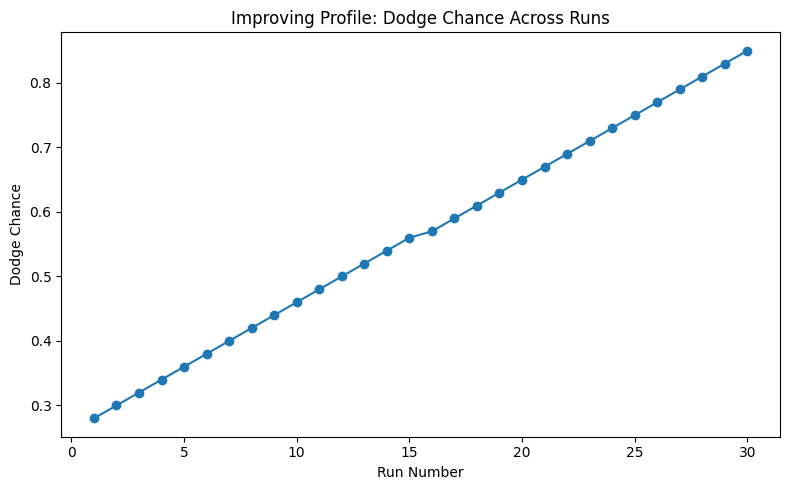

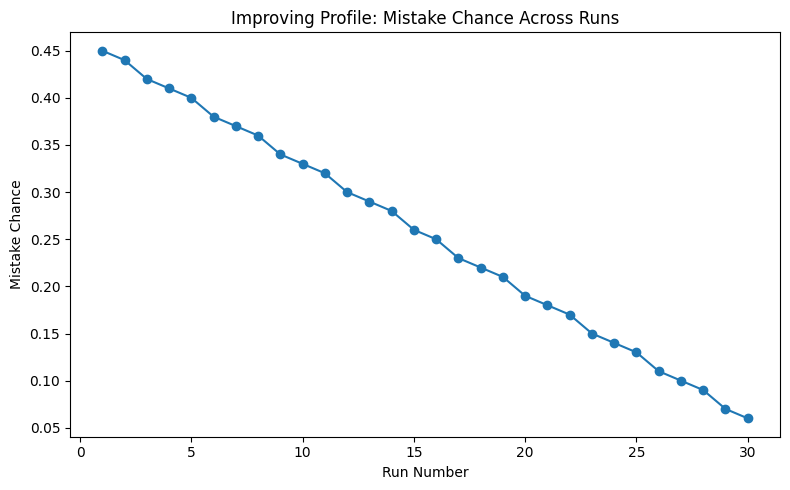

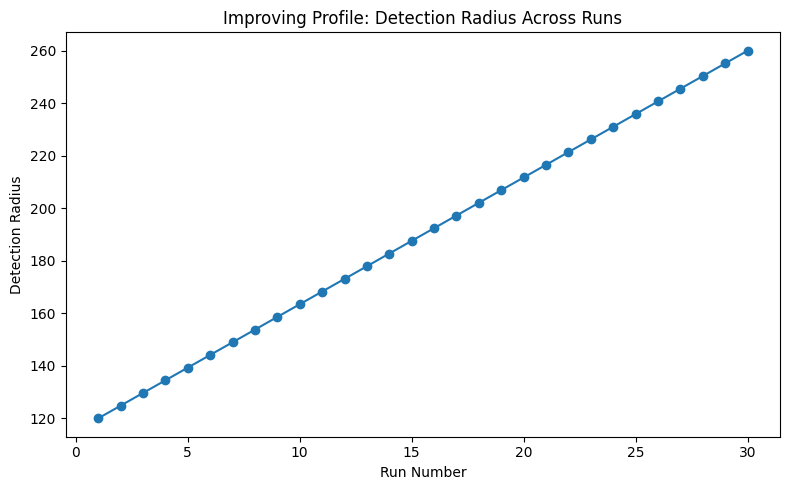

In [15]:
columns_to_plot = [
    "profile_speed",
    "profile_dodge_chance",
    "profile_mistake_chance",
    "profile_detection_radius",
]

for column in columns_to_plot:
    if column in improving.columns:
        plt.figure(figsize=(8, 5))
        plt.plot(improving["run_number"], improving[column], marker="o")
        
        readable_name = column.replace("profile_", "").replace("_", " ").title()
        plt.title(f"Improving Profile: {readable_name} Across Runs")
        plt.xlabel("Run Number")
        plt.ylabel(readable_name)
        plt.tight_layout()
        
        file_name = f"improving_profile_{column}_trend.png"
        plt.savefig(FIGURE_DIR / file_name, dpi=300)
        plt.show()

### Interpretation

These plots confirm that the improving profile changes its internal behaviour values across repeated runs. Movement speed, dodge chance, and detection radius increase steadily, while mistake chance decreases. This means the improving profile is not a fixed player profile. Instead, it gradually shifts from beginner-level behaviour toward skilled-level behaviour.

This supports the intended design of the improving profile. The later improvement in survival time can therefore be linked to the profile's changing behaviour parameters rather than being treated as random variation alone.

## 10. Inconsistent Profile Parameter Variation

The inconsistent profile randomises its internal behaviour values between runs.  
This section checks whether those values actually vary across the experiment.

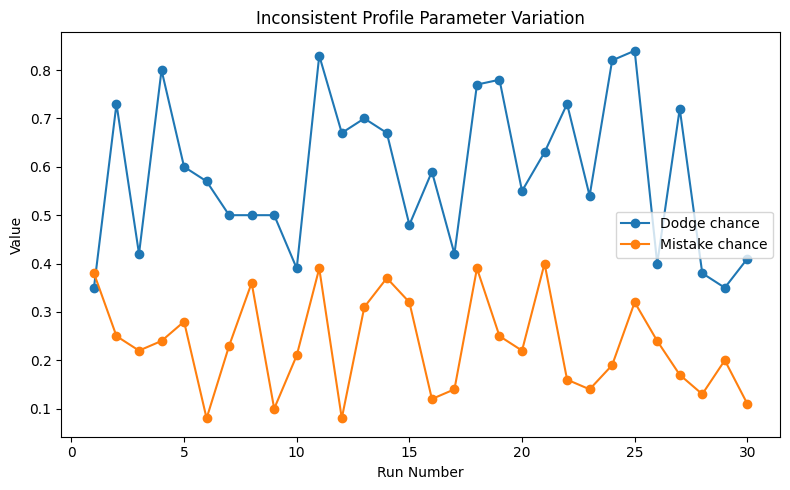

In [16]:
inconsistent = results[results["profile"] == "inconsistent"]

plt.figure(figsize=(8, 5))

plt.plot(
    inconsistent["run_number"],
    inconsistent["profile_dodge_chance"],
    marker="o",
    label="Dodge chance",
)

plt.plot(
    inconsistent["run_number"],
    inconsistent["profile_mistake_chance"],
    marker="o",
    label="Mistake chance",
)

plt.title("Inconsistent Profile Parameter Variation")
plt.xlabel("Run Number")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()

plt.savefig(FIGURE_DIR / "inconsistent_profile_parameter_variation.png", dpi=300)
plt.show()

### Interpretation

The inconsistent profile shows clear variation in its behaviour parameters across repeated runs. Dodge chance and mistake chance change from run to run rather than following a fixed trend. This confirms that the inconsistent profile represents unstable simulated player behaviour rather than a consistently weak, intermediate, or skilled player.

This variation is useful for the evaluation because an adaptive difficulty system should be able to respond to changing player performance, not only fixed skill levels.

## 11. Static Baseline Interpretation

The static baseline results show that one fixed difficulty level does not suit every simulated player profile equally.

Difficulty level 5 is calibrated for the intermediate profile, but the same setting is too hard for the beginner profile and too easy for the skilled profile.  
The inconsistent profile shows that performance can vary between runs, while the improving profile shows that performance can change over time.

These findings justify the next stage of the project: implementing adaptive difficulty systems.

In [20]:
summary_output_path = TABLE_DIR / "static_baseline_summary.csv"
summary.round(2).to_csv(summary_output_path, index=False)

summary_output_path

PosixPath('../results/tables/static_baseline_summary.csv')

## 12. Figures Saved for Report

The generated figures have been saved to the `report/figures` folder.  
These plots can be inserted into the Results section of the dissertation report.